In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms

In [49]:
def adjust_gamma(texture, image):
    texture_gray = cv2.cvtColor(texture, cv2.COLOR_BGR2GRAY)
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_texture = np.mean(texture_gray)
    mean_image = np.mean(image_gray)

    gamma_correction = np.log(mean_image / 255) / np.log(mean_texture / 255)
    gamma_correction = np.clip(
        gamma_correction, 0.5, 2.0)

    inv_gamma = 1.0 / gamma_correction
    table = np.array([(i / 255.0) ** inv_gamma *
                     255 for i in range(256)]).astype("uint8")
    corrected_texture = cv2.LUT(texture, table)

    final_texture = match_histograms(
        corrected_texture, image, channel_axis=-1)

    return final_texture.astype(np.uint8)

In [50]:
cube_img = cv2.imread('cube.jpg')
cube_img = cv2.cvtColor(cube_img, cv2.COLOR_BGR2RGB)

In [51]:
texture_img = cv2.imread('texture3.png')
texture_img = cv2.cvtColor(texture_img, cv2.COLOR_BGR2RGB)

color_filter = np.array([1.0, 0.5, 0.5])
red_texture = (texture_img * color_filter).astype(np.uint8)

plt.show()

In [52]:
cube_img.shape, texture_img.shape

((426, 394, 3), (512, 512, 3))

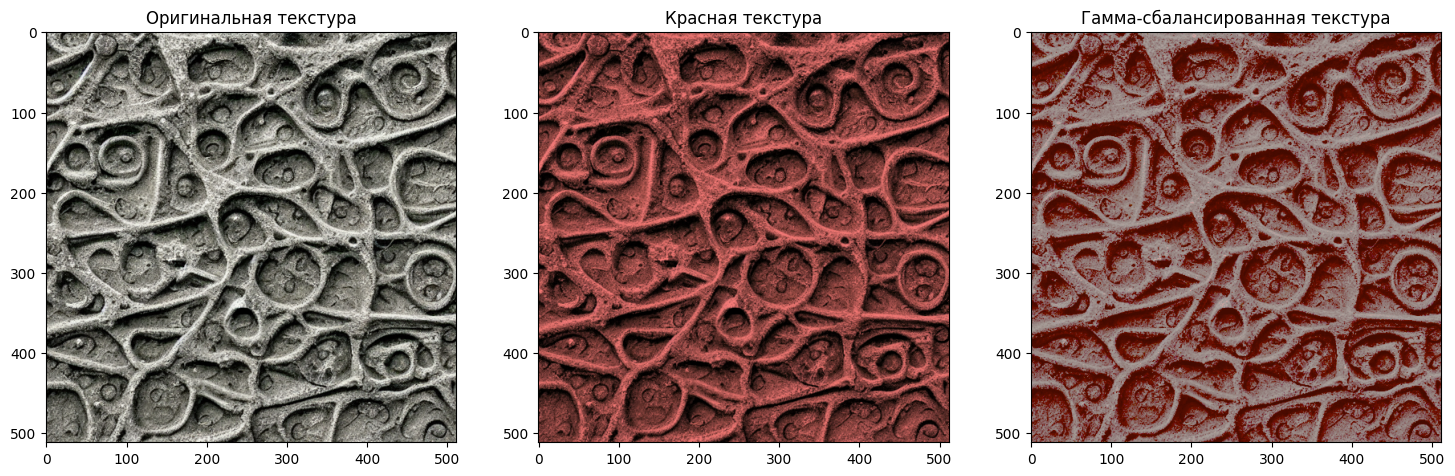

In [53]:
balanced_texture = adjust_gamma(red_texture, cube_img)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(texture_img)
axs[0].set_title("Оригинальная текстура")

axs[1].imshow(red_texture)
axs[1].set_title("Красная текстура")

axs[2].imshow(balanced_texture)
axs[2].set_title("Гамма-сбалансированная текстура")
plt.show()

In [54]:
texture_size = balanced_texture.shape[:2]
texture_points = np.array([
    [0, 0], [texture_size[1], 0], 
    [texture_size[1],
    texture_size[0]], 
    [0, texture_size[0]]
], dtype=np.float32)

In [55]:
def apply_texture_to_face(img, src_pts, dst_pts, texture):
    H, _ = cv2.findHomography(src_pts, dst_pts)
    warped_texture = cv2.warpPerspective(
        texture, H, (img.shape[1], img.shape[0]))
    mask = np.zeros_like(img, dtype=np.uint8)
    cv2.fillConvexPoly(mask, np.int32(dst_pts), (255, 255, 255))
    img = cv2.bitwise_and(img, 255 - mask) + \
        cv2.bitwise_and(warped_texture, mask)
    return img

In [56]:
def intersection(line1, line2, img_width, img_height):
    rho1, theta1 = line1
    rho2, theta2 = line2

    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([[rho1], [rho2]])

    if np.abs(np.linalg.det(A)) < 1e-10:
        return None  # Линии параллельны
    
    x0, y0 = np.linalg.solve(A, b).flatten()
    
    if x0 < 0 or x0 >= img_width or y0 < 0 or y0 >= img_height:
        return None
    
    return int(np.round(x0)), int(np.round(y0))

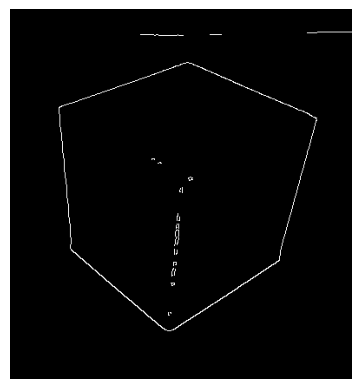

In [57]:
gray = cv2.cvtColor(cube_img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (13,13), 1, 0)
edges = cv2.Canny(gray, 60, 70)

plt.imshow(cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR))
plt.axis('off')
plt.show()

[[181 372]
 [307 291]
 [354 124]
 [206  61]
 [ 70 276]
 [ 56 113]
 [200 195]]


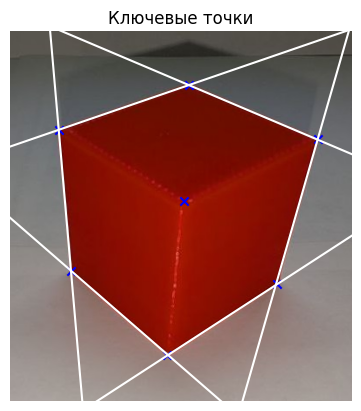

In [58]:
lines = cv2.HoughLines(edges, 1, np.pi / 180, 83)
lines = np.delete(lines[2:], 5, axis=0)
for rho, theta in lines[:, 0]:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    plt.plot([x1, x2], [y1, y2], 'white')

img_height, img_width = cube_img.shape[:2]

cube_pts = []
for i in range(len(lines)):
    for j in range(i + 1, len(lines)):
        line1 = lines[i][0]
        line2 = lines[j][0]
        point = intersection(line1, line2, img_width, img_height)
        if point is not None:
            cube_pts.append(point)

cube_pts.append((200, 195))
cube_pts = np.array(cube_pts)

print(cube_pts)
plt.scatter(cube_pts[:, 0], cube_pts[:, 1], c='blue', marker='x')
plt.title('Ключевые точки')
plt.imshow(cube_img, cmap='gray')
plt.axis('off')
plt.show()

In [59]:
left_face = np.array([
    cube_pts[5], cube_pts[6], cube_pts[0], cube_pts[4]
])
right_face = np.array([
    cube_pts[6], cube_pts[2], cube_pts[1], cube_pts[0]
])
top_face = np.array([
    cube_pts[5], cube_pts[3], cube_pts[2], cube_pts[6]
])

In [60]:
cube_img = apply_texture_to_face(
    cube_img, texture_points, left_face, balanced_texture)
cube_img = apply_texture_to_face(
    cube_img, texture_points, right_face, balanced_texture)
cube_img = apply_texture_to_face(
    cube_img, texture_points, top_face, balanced_texture)

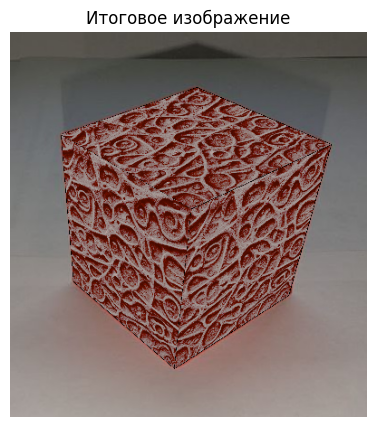

In [61]:
plt.figure(figsize=(10, 5))
plt.imshow(cube_img)
plt.title('Итоговое изображение')
plt.axis('off')
plt.show()